# FaceCloak Technical Walkthrough
This notebook walks through a single complete cloaking operation, exposing the mathematics and intermediate tensors step by step.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from facecloak.models import get_face_detector, get_embedding_model
from facecloak.pipeline import detect_primary_face, extract_embedding_numpy, cosine_similarity
from facecloak.cloaking import cloak_face_tensor, CloakHyperparameters

## 1. Load Original Image & Face Detection

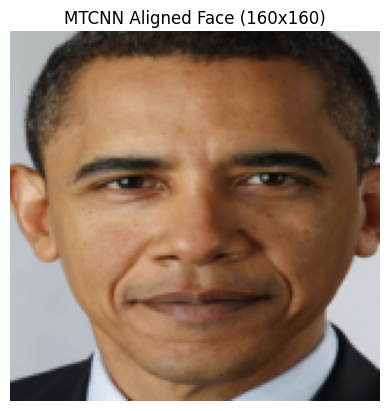

In [2]:
img = Image.open(Path('tests/fixtures/faces/obama_a.jpg')).convert('RGB')
detected = detect_primary_face(img)
plt.imshow(detected.image)
plt.title('MTCNN Aligned Face (160x160)')
plt.axis('off')
plt.show()

## 2. Baseline Embedding
The model (InceptionResnetV1) embeds this face into a 512-dimensional vector. We will track how this embedding moves during the attack.

In [3]:
orig_embedding = extract_embedding_numpy(detected.tensor)
print(f'Original embedding shape: {orig_embedding.shape}')
print(f'Original embedding L2 norm: {np.linalg.norm(orig_embedding):.4f}')

Original embedding shape: (512,)
Original embedding L2 norm: 1.0000


## 3. Projected Gradient Descent
We run 100 steps of L-infinity PGD with epsilon=0.03. We capture the perturbation at multiple steps.

In [4]:
result = cloak_face_tensor(detected.tensor, parameters=CloakHyperparameters(epsilon=0.03, num_steps=100))

## 4. Visualizing Adversarial Noise
To humans, the modification is completely invisible. The amplitude is tiny (<= 0.03 normalized). We amplify it by 75x to visualize its structure.

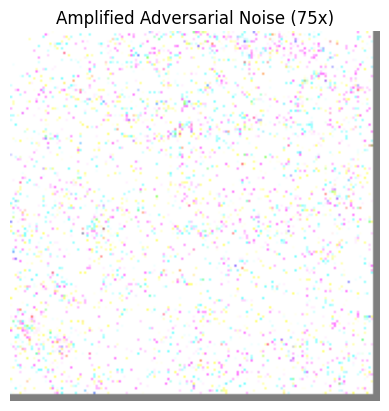

In [5]:
plt.imshow(result.amplified_diff)
plt.title('Amplified Adversarial Noise (75x)')
plt.axis('off')
plt.show()

## 5. Resulting Cloak
The final cloaked embedding is drastically far in cosine distance from the original.

Original Vs Original Similarity: 1.0000
Original Vs Cloaked Similarity: -0.0164


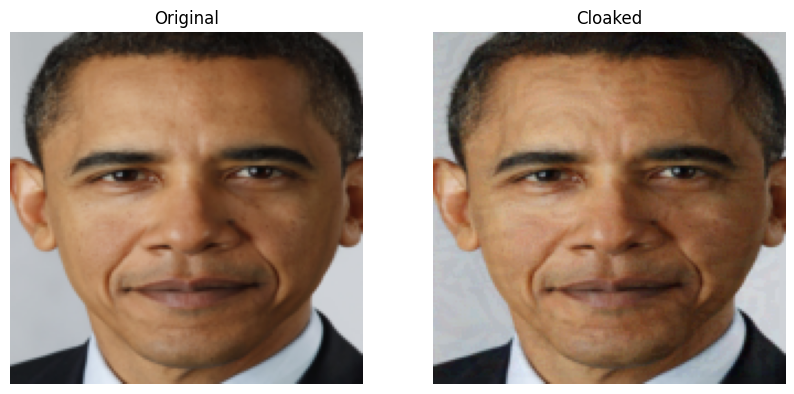

In [6]:
print(f'Original Vs Original Similarity: {cosine_similarity(orig_embedding, orig_embedding):.4f}')
print(f'Original Vs Cloaked Similarity: {result.final_similarity:.4f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.imshow(detected.image)
ax1.set_title('Original')
ax1.axis('off')
ax2.imshow(result.cloaked_face_image)
ax2.set_title('Cloaked')
ax2.axis('off')
plt.show()